In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# Geomagnetic Storm Prediction from Cosmic Ray Measurements

## Abstract
This project investigates whether ground-based cosmic ray neutron monitor data, combined with near-Earth solar wind parameters, can be used to forecast the intensity of geomagnetic storms several hours in advance. The target variable is the Disturbance Storm Time (Dst) index, a standard measure of geomagnetic activity. The domain is Space Weather — specifically CME-driven geomagnetic disturbances — over the period 1981–2023.  

Two data sources are used: hourly neutron count rates from the Lomnický štít station (LMKS), provided by Kisvárdai et al. (2024), and hourly solar wind parameters from the NASA OMNI dataset (Papitashvili & King, 2020). After joint cleaning and feature engineering, the merged dataset spans 364,728 hourly observations across solar cycles 21–25.

## Introduction

This project belongs to the field of *Space Weather* — the study of how solar activity affects near-Earth space and, consequently, technological infrastructure on the ground and in orbit. Severe geomagnetic storms can induce geomagnetically induced currents (GICs) in power grid infrastructure, disrupt satellite navigation and radio communications, accelerate orbital decay of low-Earth-orbit satellites, and pose radiation hazards to astronauts and high-altitude aviation. A forecast with several hours of lead time allows grid operators, satellite controllers, and mission planners to take protective action. The practical operational minimum is one hour; longer horizons of $6$–$24$ hours are actively sought by the space weather community `[ISH17]`.


### Domain Definition

A geomagnetic storm is not a single event but a chain of causally connected phenomena, each of which leaves a measurable trace.

**Stage 1 — Eruption at the Sun.** During periods of high solar activity, magnetically stressed regions on the solar surface can release large quantities of magnetized plasma into interplanetary space — a *coronal mass ejection* (CME). A CME is accompanied by a fast-forward shock wave propagating ahead of it. The overall level of solar activity follows an approximately $11$-year cycle, which means that the frequency and intensity of CMEs — and consequently of geomagnetic storms — is not constant over time but rises and falls with the cycle. 

<img src="images/fig1_chain.png" style="width:80%; max-width:700px"/>  

*Figure 1 — The Sun–L1–Earth chain. Synthetic illustration.*


**Stage 2 — Propagation through interplanetary space.** The CME and its preceding shock travel outward from the Sun at speeds ranging from $300$ to $2{,}000\ \text{km/s}$. As the shock propagates, it sweeps aside galactic cosmic rays — high-energy charged particles that arrive continuously at Earth from outside the solar system. This sweeping creates a temporary deficit of cosmic rays, called a **Forbush Decrease**, which can be detected at ground level by a neutron monitor hours before the CME itself arrives at Earth `[KIS25]`. The Forbush Decrease is therefore a precursor signal embedded in the cosmic ray record.  

<img src="images/fig2_forbush_dst.png" style="width:70%; max-width:600px"/>  

*Figure 2 — Synthetic Forbush Decrease and $D_{st}$ response. For illustration only.*  

**Stage 3 — Arrival at L1 and the solar wind parameters.** Before reaching Earth, the CME passes through the **L1 Lagrange point** — a gravitationally stable location in space approximately $1.5 \times 10^6\ \text{km}$ upstream of Earth, where the gravitational pull of the Sun and Earth balance the centrifugal force on an orbiting body. Spacecraft stationed at L1 have an unobstructed view of the incoming solar wind and measure its properties continuously in near-real time: the speed $V_{sw}\ [\text{km/s}]$, the proton density $n_p\ [\text{cm}^{-3}]$, the plasma temperature $T\ [\text{K}]$, and — most critically for storm prediction — the north-south component of the interplanetary magnetic field $B_z\ [\text{nT}]$ `[PAP20]`, `[KIN05]`. When $B_z$ is directed southward ($B_z < 0$) and remains so for an extended period, the solar wind couples efficiently to Earth's magnetosphere through a process called magnetic reconnection.

**Stage 4 — Energy injection into the magnetosphere.** The rate at which energy enters the magnetosphere depends on the interplanetary electric field:

$$E_y = -V_{sw} \cdot B_z \cdot 10^{-3} \quad [\text{mV/m}]$$

A large positive $E_y$ — produced by high solar wind speed combined with strong southward $B_z$ — drives energetic particles into a toroidal current circulating around Earth at altitudes of $2$–$9\ R_E$, known as the *ring current*. The intensification of this current depresses Earth's horizontal magnetic field at low latitudes. The classical description of this process is given by the Burton et al. (1975) equation `[BUR75]`:

$$\frac{dD_{st}}{dt} = Q(E_y) - \frac{D_{st}}{\tau}$$

where $Q(E_y)$ is the injection rate and $D_{st}/\tau$ is the natural decay of the ring current with characteristic time $\tau \approx 7$–$8$ hours. The injection function is:

$$Q(E_y) = \begin{cases} -4.4\,(E_y - 0.5) & \text{if } E_y > 0.5\ \text{mV/m} \\ 0 & \text{otherwise} \end{cases}$$

<img src="images/fig3_burton.png" style="width:60%; max-width:700px"/>  

*Figure 3 — Burton (1975) physical model `[BUR75]`. Synthetic $E_y(t)$ profile.*  


**Stage 5 — Ground-level response.** The depression of the horizontal magnetic field is recorded at a network of low-latitude observatories and averaged into the **Disturbance Storm Time ($D_{st}$) index** `[WDC]`, expressed in nanotesla ($\text{nT}$). This is the target variable of the present project. Storm severity is conventionally classified as:

$$D_{st} > -50\ \text{nT} \quad \text{(quiet)}$$
$$-100\ \text{nT} < D_{st} \leq -50\ \text{nT} \quad \text{(moderate storm)}$$
$$-200\ \text{nT} < D_{st} \leq -100\ \text{nT} \quad \text{(strong storm)}$$
$$D_{st} \leq -200\ \text{nT} \quad \text{(extreme storm)}$$

The decay time $\tau \approx 7$–$8$ hours from the Burton equation defines the natural timescale of storm evolution and motivates the choice of prediction horizons examined in this project. The physical travel time of a CME shock from the Sun to L1 ($1$–$4$ days) and the L1-to-Earth propagation time ($15$–$60$ minutes) jointly constrain the range of horizons for which ground-based and in-situ measurements can plausibly carry predictive information: between $1$ and approximately $72$ hours `[PAR10]`, `[ISH17]`.

### Prior Work

The Burton et al. (1975) equation `[BUR75]` established the classical physical relationship between $E_y$ and $D_{st}$, providing a physically interpretable baseline that remains in use today. More recent machine learning approaches have extended this to multi-hour prediction: Parnowski (2010) `[PAR10]` reports $R^2 > 0.90$ at $1$–$6$ hour horizons using OMNI solar wind parameters alone. The MagNet competition `[NAI23]` benchmarked a broad range of models — from linear regression to deep neural networks — achieving RMSE in the range of $11$–$15\ \text{nT}$ at a $1$-hour horizon. Hu et al. (2023) `[HU23]` applied multi-fidelity boosted neural networks with explicit prediction intervals, further demonstrating the value of uncertainty quantification in operational forecasting.

**Gap.** Most published models rely exclusively on in-situ solar wind measurements at L1, which provide at most $15$–$60$ minutes of natural lead time before the disturbance reaches Earth. The Forbush Decrease — described in Stage 2 above — offers a physically distinct signal that precedes the storm's main phase by several hours. Kisvárdai et al. (2025) `[KIS25]` analyzed $42$ years of neutron monitor data from the Lomnický štít station and found a Pearson correlation of $r = 0.314$ between the neutron flux and $D_{st}$ at a time shift of $7$–$21$ hours, and a predictive power score of $\text{PPS} = 0.22$. This suggests that the cosmic ray signal carries information about future storm intensity beyond what the instantaneous solar wind parameters alone capture.

**Contribution.** This project investigates whether combining cosmic ray neutron flux measurements `[KIS24]` with OMNI solar wind parameters `[PAP20]` can extend the useful prediction horizon and improve forecast skill relative to OMNI-only models.

**Scope.** The analysis is restricted to CME-driven storms over the period $1981$–$2023$. The dataset is not filtered by storm driver type — Co-rotating Interaction Region (CIR) driven storms, which follow a different physical mechanism and do not produce a Forbush Decrease precursor, remain in the record and represent a source of noise for the cosmic ray features. This is acknowledged as a limitation of the present study.


## Methods

This section states the pre-registered assumptions and known limitations of the study. All modelling decisions — feature engineering, train/validation/test split, and model selection — are declared here, before any data is loaded, to avoid post-hoc rationalisation.

### Assumptions

**Problem formulation.** The task is supervised regression: given a window of past observations ending at time $t$, predict $D_{st}(t + h)$ for a lead time $h \in \{1, 3, 7, 12, 21\}$ hours. These horizons span short-term operational forecasting ($1$–$3$ h), the Burton ring current decay timescale ($7$ h), and the upper range of the observed neutron–$D_{st}$ lag reported by Kisvárdai et al. (2025) `[KIS25]` ($21$ h). A secondary formulation treats the problem as binary classification — storm / no-storm — with threshold $D_{st} \leq -50\ \text{nT}$, following the NOAA moderate storm convention `[WDC]`.

**Hypotheses.**

- $H_{skill}$: A model trained on the differential neutron flux $\delta n(t)$ and OMNI solar wind parameters achieves $R^2 \geq 0.60$ at a lead time of $h = 7$ hours on the held-out test set (solar cycles 24–25, 2008–2023).
- $H_{gain}$: A model trained on OMNI solar wind parameters combined with $\delta n(t)$ achieves a higher $R^2$ at $h \geq 7$ hours than an equivalent model trained on OMNI parameters alone.

The differential neutron flux is defined as:

$$\delta n(t) = \frac{N(t) - N(t - w)}{N(t - w)}$$

where $N(t)$ is the hourly neutron count rate from the LMKS station `[KIS24]` and $w$ is the differencing window. A value of $w = 7$ hours is chosen on two grounds: Kisvárdai et al. (2025) `[KIS25]` find that the Pearson correlation between the LMKS neutron flux and $D_{st}$ is maximised at a time shift of $7$–$21$ hours; and the characteristic ring current decay time $\tau \approx 7$–$8$ hours from the Burton equation `[BUR75]` provides a physically motivated lower bound for this range.

**Success threshold.** The target threshold of $R^2 \geq 0.60$ at $h = 7$ hours is motivated by three reference points from the literature: Parnowski (2010) `[PAR10]` reports $R^2 > 0.90$ at $h = 1$–$6$ hours using OMNI alone, establishing an upper bound for short horizons; the MagNet competition `[NAI23]` reports RMSE of $11$–$15\ \text{nT}$ at $h = 1$ hour; and Kisvárdai et al. (2025) `[KIS25]` report a predictive power score of $\text{PPS} = 0.22$ for neutron flux alone, establishing that the cosmic ray signal has non-trivial but modest predictive value. Direct comparison across these studies is imperfect as the reported metrics differ. A threshold of $R^2 = 0.60$ at $h = 7$ hours represents a meaningful improvement over the cosmic-ray-only baseline while remaining below the OMNI-only performance at short horizons.

**Evaluation metrics.** Primary metric: $R^2$ (coefficient of determination). Secondary metrics: RMSE $[\text{nT}]$ and MAE $[\text{nT}]$. Given the strong class imbalance — quiet conditions ($D_{st} > -50\ \text{nT}$) dominate the record — a model that predicts values near zero at all times would achieve a deceptively high $R^2$. For this reason, evaluation is performed both on the full test set and separately on the storm subset ($D_{st} \leq -50\ \text{nT}$), reporting RMSE and MAE for each subset independently. For the classification formulation, the Precision-Recall curve and $F_1$ score are reported in preference to accuracy, since missing a storm (false negative) carries a higher operational cost than a false alarm.


### Limitations

**Single neutron monitor station.** The LMKS dataset represents measurements at a single point on Earth's surface (Lomnický štít, Slovakia, $2{,}634\ \text{m}$, geomagnetic cutoff rigidity $\approx 3.98\ \text{GV}$) `[KIS24]`. The amplitude of a Forbush Decrease depends on the relative geometry between the CME propagation direction and the observer. CMEs directed away from the Sun–Earth line may produce a weak or absent Forbush Decrease at LMKS even when they cause a significant geomagnetic storm.

**No CIR storm filtering.** The dataset is not filtered by storm driver type. Co-rotating Interaction Region (CIR) driven storms — which are caused by the interaction of fast and slow solar wind streams and do not produce a Forbush Decrease precursor — are present in the record and act as noise for the neutron flux features. Their removal would require an independent CME catalogue, which is outside the scope of this project.

**Sensor changes over 42 years.** The LMKS neutron monitor record spans 1981–2023 and covers multiple instrument upgrades. Long-term trends in the count rate baseline may reflect instrumental changes rather than physical variability. This is examined in IDA.

**Data leakage risk.** When constructing lag features $\delta n(t)$ and shifted $D_{st}$ targets, all transformations must be applied strictly within the training period before being applied to validation and test sets. Any normalisation or scaling parameters are fitted on the training set only.

**Forecast horizon constraint.** The analysis is restricted to horizons $h \leq 21$ hours. At longer horizons, the coherence of interplanetary structures degrades and the physical basis for prediction weakens `[ISH17]`.

## Initial Data Analysis (IDA)

This section documents the properties of the two raw datasets as received, without any modifications. All observations are descriptive — no values are removed or imputed here.


### Data Sources

Two datasets are used in this project:

**OMNI** `[PAP20]`, `[KIN05]` — hourly averages of solar wind magnetic field and plasma parameters measured at the L1 Lagrange point, compiled by NASA/GSFC Space Physics Data Facility. Column descriptions are taken directly from the accompanying format file `omni2_6HWKguLfs2.fmt`.

**LMKS** `[KIS24]` — hourly neutron count rates from the Lomnický štít neutron monitor (Slovakia, 2,634 m altitude), spanning solar cycles 21–25.

We begin by loading both datasets in their raw form and inspecting their structure — column names, data types, shape, and first rows — without any modifications.


In [13]:
# Parse column names from fmt file
with open('data/input/omni2_6HWKguLfs2.fmt', 'r') as f:
    lines = f.readlines()

col_names = []
for line in lines:
    match = re.match(r'\s*\d+\s+(.+?)\s+[IF]\d', line)
    if match:
        name = match.group(1).strip()
        col_names.append(name)

# Load data
df_omni = pd.read_csv('data/input/omni2_6HWKguLfs2.lst', sep=r'\s+', header=None, names=col_names)
print("\n=== OMNI — first 5 rows ===")
print(df_omni.head())
print("\n=== OMNI — shape ===")
print(df_omni.shape)
print("\n=== OMNI — dtypes ===")
print(df_omni.dtypes)


=== OMNI — first 5 rows ===
   YEAR  DOY  Hour  Bartels rotation number  ID for IMF spacecraft  \
0  1981  335     0                     2027                     13   
1  1981  335     1                     2027                     13   
2  1981  335     2                     2027                     13   
3  1981  335     3                     2027                     13   
4  1981  335     4                     2027                     13   

   ID for SW Plasma spacecraft  # of points in IMF averages  \
0                           13                           30   
1                           13                           29   
2                           13                           30   
3                           13                           31   
4                           13                           29   

   # of points in Plasma averag.  Scalar B, nT  Vector B Magnitude,nT  ...  \
0                            999           6.3                    6.0  ...   
1              


**OMNI column groups** `[KIN05]`, `[PAP20]`:

The 57 columns are organised into six physical groups:

**Time** (`YEAR`, `DOY`, `Hour`) — hourly timestamp encoded as year, day-of-year, and hour.

**Administrative** (`Bartels rotation number`, `ID for IMF spacecraft`, `ID for SW Plasma spacecraft`, `# of points in IMF averages`, `# of points in Plasma averag.`) — metadata describing which spacecraft provided the measurements and how many 1-minute samples were averaged into each hourly value.

**Interplanetary Magnetic Field — IMF** (`Scalar B`, `Vector B`, `Bx/By/Bz GSE`, `By/Bz GSM`, `RMS_*`) — the magnetic field carried by the solar wind. The north-south component $B_z$ in GSM coordinates is the primary driver of geomagnetic storms via the Burton injection function `[BUR75]`.

**Solar Wind Plasma** (`T_p`, `n_p`, `V_sw`, flow angles, `Alpha/Prot. ratio`, sigma fields) — bulk properties of the solar wind plasma. Solar wind speed $V_{sw}$ combined with $B_z$ determines the interplanetary electric field $E_y = -V_{sw} \cdot B_z \cdot 10^{-3}$.

**Derived and activity indices** (`P_flow`, `E_field`, `Plasma Beta`, `Alfven mach`, `MS mach`, `QI`, `Kp`, `R_sunspot`, `Dst`, `ap`, `f10.7`, `AE`, `AL`, `AU`, `pc`) — quantities derived from the above measurements or independently observed. `Dst-index, nT` is the target variable of this project.

**Energetic particle flux** (`Lyman_alpha`, proton flux $>1$–$60$ MeV, `Flux FLAG`) — solar energetic particle measurements. Elevated flux values coincide with solar energetic particle events and Ground Level Enhancements (GLEs) — physically distinct from the Forbush Decrease signal of interest.

> **Observations — OMNI:**
> - Shape: 365,232 rows × 57 columns.
> - Column names loaded directly from `omni2_6HWKguLfs2.fmt` `[KIN05]`.
> - Dtypes match the format file: time and index columns are `int64`; physical measurements are `float64`.
> - Fill values are already visible in the first 5 rows: `999999.99` in proton flux columns and `0` in `Flux FLAG` — require further investigation.
> - `# of points in Plasma averag.` shows value `999` in the first rows — likely a fill value, not a physical count.
> - No `NaN` values present at this stage — missing data is encoded as sentinel fill values.

In [14]:
df_lmks = pd.read_csv('data/input/LMKS_NM_1981-2023_h.csv')

print("\n=== LMKS — first 5 rows ===")
print(df_lmks.head())
print("\n=== LMKS — dtypes ===")
print(df_lmks.dtypes)


=== LMKS — first 5 rows ===
              datetime  lmks_nm_counts
0  1981-12-01 00:00:00          87.268
1  1981-12-01 01:00:00          86.924
2  1981-12-01 02:00:00          86.867
3  1981-12-01 03:00:00          86.408
4  1981-12-01 04:00:00          86.523

=== LMKS — dtypes ===
datetime           object
lmks_nm_counts    float64
dtype: object


> **Observations — LMKS:**
> - Shape: 2 columns — `datetime` (object) and `lmks_nm_counts` (float64).
> - `datetime` is loaded as `object`, not as a datetime type.
> - `lmks_nm_counts` values in the first rows are in the range 86–87 counts/min.
> - The dataset starts at `1981-12-01 00:00:00` — eleven months later than OMNI which starts at `1981-01-01`.
> - No fill values visible in the first rows.

### Missing Values

The OMNI dataset does not use `NaN` to encode missing measurements. Instead, each column has a designated sentinel fill value, documented in the OMNI data documentation `[KIN05]`. The fill values are physically impossible — they fall far outside the valid measurement range for each variable. We verify their presence by inspecting the maximum values from `describe()`.


In [26]:
fill_map = {
    'Scalar B, nT':                999.9,
    'Vector B Magnitude,nT':       999.9,
    'Lat. Angle of B (GSE)':       999.9,
    'Long. Angle of B (GSE)':      999.9,
    'BX, nT (GSE, GSM)':           999.9,
    'BY, nT (GSE)':                999.9,
    'BZ, nT (GSE)':                999.9,
    'BY, nT (GSM)':                999.9,
    'BZ, nT (GSM)':                999.9,
    'RMS_magnitude, nT':           999.9,
    'RMS_field_vector, nT':        999.9,
    'RMS_BX_GSE, nT':              999.9,
    'RMS_BY_GSE, nT':              999.9,
    'RMS_BZ_GSE, nT':              999.9,
    'SW Plasma Temperature, K':    9999999.,
    'SW Proton Density, N/cm^3':   999.9,
    'SW Plasma Speed, km/s':       9999.,
    'SW Plasma flow long. angle':  999.9,
    'SW Plasma flow lat. angle':   999.9,
    'Alpha/Prot. ratio':           9.999,
    'sigma-T,K':                   9999999.,
    'sigma-n, N/cm^3)':            999.9,
    'sigma-V, km/s':               9999.,
    'sigma-phi V, degrees':        999.9,
    'sigma-theta V, degrees':      999.9,
    'sigma-ratio':                 9.999,
    'Flow pressure':               99.99,
    'E elecrtric field':           999.99,
    'Plasma Beta':                 999.99,
    'Alfen mach number':           999.9,
    'Magnetosonic Much num.':      99.9,
    'Quasy-Invariant':             9.9999,
    'Kp index':                    99,
    'R (Sunspot No.)':             999,
    'Dst-index, nT':               99999,
    'ap_index, nT':                999,
    'f10.7_index':                 999.9,
    'AE-index, nT':                99999,
    'AL-index, nT':                99999,
    'AU-index, nT':                99999,
    'pc-index':                    999.9,
    'Lyman_alpha':                 0.999999,
    'Proton flux (>1 Mev)':        999999.99,
    'Proton flux (>2 Mev)':        99999.99,
    'Proton flux (>4 Mev)':        99999.99,
    'Proton flux (>10 Mev)':       99999.99,
    'Proton flux (>30 Mev)':       99999.99,
    'Proton flux (>60 Mev)':       99999.99,
    'Flux FLAG':                   -1,
}

groups_missing = {
    'IMF': [
        'Scalar B, nT', 'Vector B Magnitude,nT', 'Lat. Angle of B (GSE)',
        'Long. Angle of B (GSE)', 'BX, nT (GSE, GSM)', 'BY, nT (GSE)',
        'BZ, nT (GSE)', 'BY, nT (GSM)', 'BZ, nT (GSM)',
        'RMS_magnitude, nT', 'RMS_field_vector, nT',
        'RMS_BX_GSE, nT', 'RMS_BY_GSE, nT', 'RMS_BZ_GSE, nT',
    ],
    'Solar Wind Plasma': [
        'SW Plasma Temperature, K', 'SW Proton Density, N/cm^3',
        'SW Plasma Speed, km/s', 'SW Plasma flow long. angle',
        'SW Plasma flow lat. angle', 'Alpha/Prot. ratio',
    ],
    'Sigma (quality indicators)': [
        'sigma-T,K', 'sigma-n, N/cm^3)', 'sigma-V, km/s',
        'sigma-phi V, degrees', 'sigma-theta V, degrees', 'sigma-ratio',
    ],
    'Derived': [
        'Flow pressure', 'E elecrtric field', 'Plasma Beta',
        'Alfen mach number', 'Magnetosonic Much num.', 'Quasy-Invariant',
    ],
    'Geomagnetic indices': [
        'f10.7_index', 'AL-index, nT', 'AU-index, nT', 'pc-index',
    ],
    'Proton Flux': [
        'Proton flux (>1 Mev)', 'Proton flux (>2 Mev)', 'Proton flux (>4 Mev)',
        'Proton flux (>10 Mev)', 'Proton flux (>30 Mev)', 'Proton flux (>60 Mev)',
        'Flux FLAG',
    ],
}

for group_name, cols in groups_missing.items():
    print(f"\n{'─'*60}")
    print(f"  {group_name}")
    print(f"{'─'*60}")
    print(f"  {'Column':<35} {'Missing':>8}  {'%':>6}")
    print(f"  {'-'*52}")
    for col in cols:
        if col in fill_map:
            n   = (df_omni[col] == fill_map[col]).sum()
            pct = 100 * n / len(df_omni)
            flag = '  ← candidate for exclusion' if pct > 50 else ''
            print(f"  {col:<35} {n:>8}  {pct:>5.1f}%{flag}")




────────────────────────────────────────────────────────────
  IMF
────────────────────────────────────────────────────────────
  Column                               Missing       %
  ----------------------------------------------------
  Scalar B, nT                           64660   17.7%
  Vector B Magnitude,nT                  64660   17.7%
  Lat. Angle of B (GSE)                  64660   17.7%
  Long. Angle of B (GSE)                 64660   17.7%
  BX, nT (GSE, GSM)                      64660   17.7%
  BY, nT (GSE)                           64660   17.7%
  BZ, nT (GSE)                           64660   17.7%
  BY, nT (GSM)                           64686   17.7%
  BZ, nT (GSM)                           64686   17.7%
  RMS_magnitude, nT                      64763   17.7%
  RMS_field_vector, nT                   64715   17.7%
  RMS_BX_GSE, nT                         64729   17.7%
  RMS_BY_GSE, nT                         64720   17.7%
  RMS_BZ_GSE, nT                         64720

**Observations — OMNI missing values** `[KIN05]`:

The OMNI dataset encodes missing measurements with sentinel fill values. After verifying against the OMNI documentation `[KIN05]`, the following patterns emerge:

**IMF group** (all B field components and RMS): uniform 17.7% missing across all 14 columns — indicating that IMF measurements are missing as a block, consistent with periods when no IMF spacecraft was available (`ID for IMF spacecraft = 99`).

**Solar wind plasma group**: missing rates between 18.8% (`V_sw`) and 28.7% (`Alpha/Prot. ratio`). The `Alpha/Prot. ratio` stands out at 28.7% — from the documentation this is a known systematic gap after 2018 `[KIS24]`.

**Derived quantities** (`E_field`, `Plasma Beta`, `Alfven mach`, `MS mach`): 19.4%–21.7% missing — consistent with missing plasma measurements from which they are derived.

**Geomagnetic indices** (`Kp`, `R`, `Dst`, `ap`, `AE`): 0% missing — confirmed by the 6 columns with fill value never observed.

**Proton flux** (`>1`, `>2`, `>4` MeV): 64.1% missing — more than half the record. These columns are candidates for exclusion.

**Flux FLAG**: 61.6% of rows have value `-1` (no proton flux data) — consistent with the proton flux missing pattern.

In [20]:
print("\n=== LMKS missing values ===")
print(df_lmks.isnull().sum())


=== LMKS missing values ===
datetime           0
lmks_nm_counts    24
dtype: int64


**LMKS**: 24 NaN values out of 364,728 rows ($< 0.01\%$) — negligible.

**Missing Value Patterns**

We visualise the distribution of missing values across time and columns to identify whether gaps are random or systematic — concentrated in specific periods or correlated across columns.


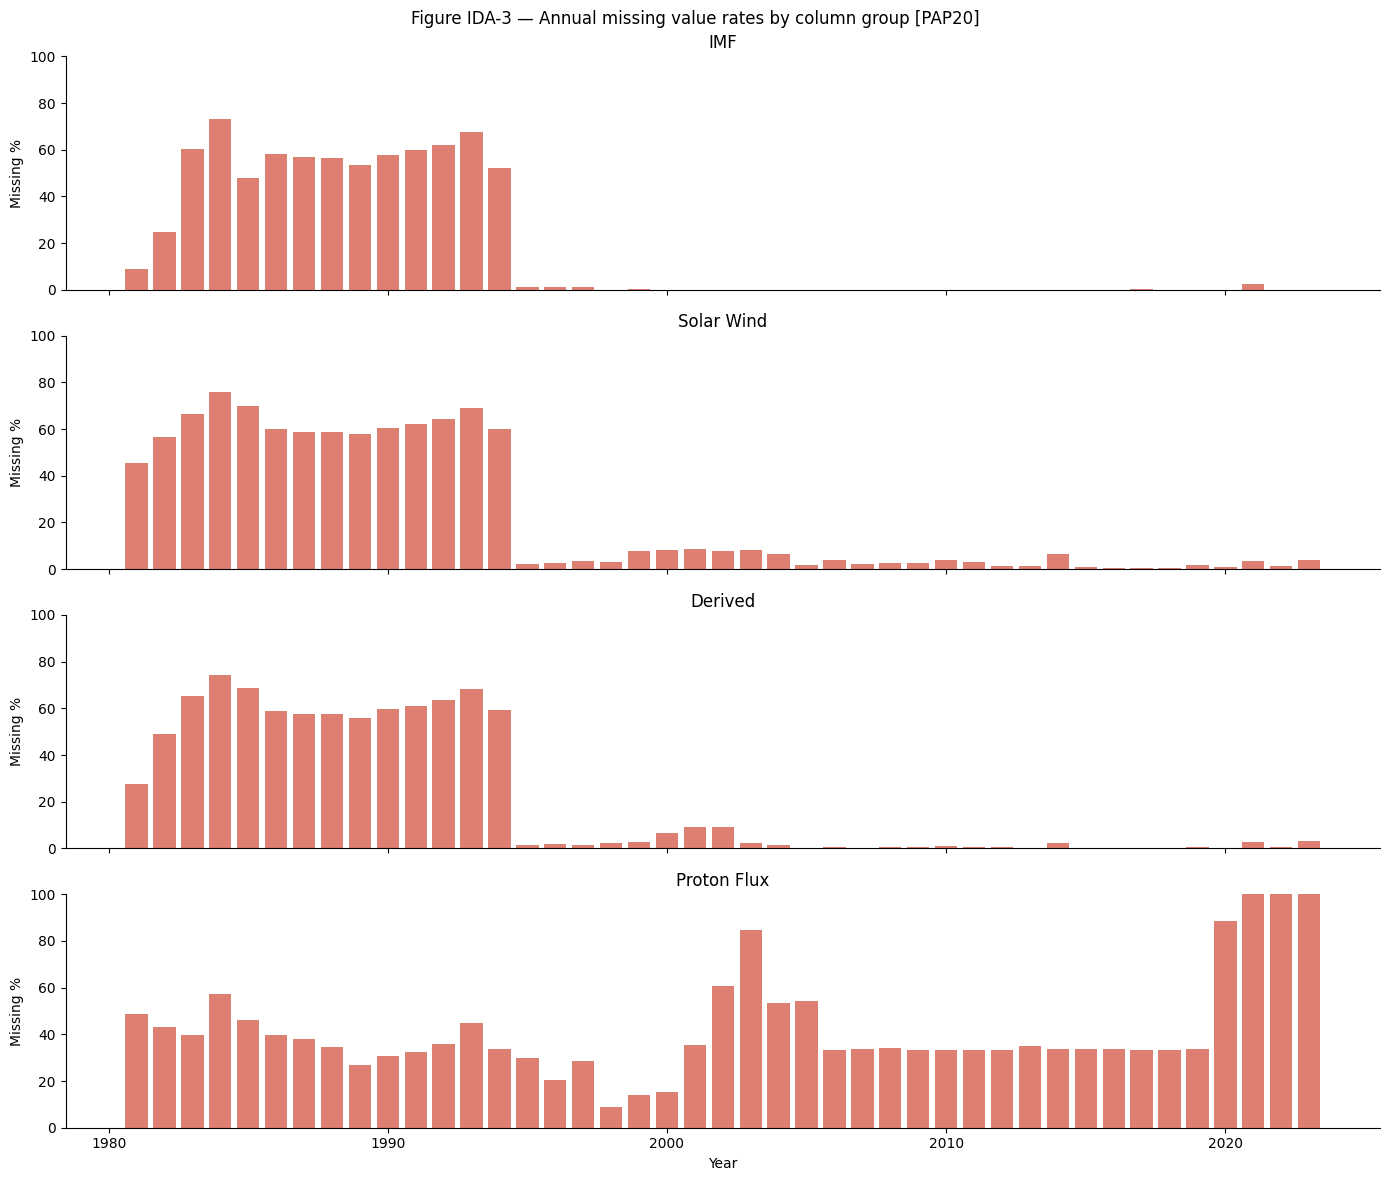

In [27]:
df_viz = df_omni.copy()
for col, fv in fill_map.items():
    df_viz[col] = df_viz[col].replace(fv, np.nan)

df_viz['YEAR'] = df_omni['YEAR']

groups = {
    'IMF':         ['BZ, nT (GSM)', 'BY, nT (GSM)', 'BX, nT (GSE, GSM)', 'Scalar B, nT'],
    'Solar Wind':  ['SW Plasma Speed, km/s', 'SW Proton Density, N/cm^3',
                    'SW Plasma Temperature, K', 'Alpha/Prot. ratio'],
    'Derived':     ['E elecrtric field', 'Flow pressure', 'Plasma Beta', 'Alfen mach number'],
    'Proton Flux': ['Proton flux (>1 Mev)', 'Proton flux (>10 Mev)', 'Proton flux (>60 Mev)'],
}

fig, axes = plt.subplots(len(groups), 1, figsize=(14, 12), sharex=True)

for ax, (group_name, cols) in zip(axes, groups.items()):
    annual_missing = df_viz.groupby('YEAR')[cols].apply(
        lambda x: x.isnull().mean().mean() * 100
    )
    ax.bar(annual_missing.index, annual_missing, color='#d6604d', alpha=0.8, width=0.8)
    ax.set_ylabel('Missing %')
    ax.set_title(group_name)
    ax.set_ylim(0, 100)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('Year')
plt.suptitle('Figure IDA-3 — Annual missing value rates by column group [PAP20]', fontsize=12)
plt.tight_layout()
plt.savefig('images/fig_ida3_missing_patterns.png', dpi=150, bbox_inches='tight')
plt.show()


**Observations — Figure IDA-3:**

**IMF group:** Missing rates are high (50–75%) throughout 1981–1995, then drop to near zero after ~1996 — consistent with the transition to continuous L1 monitoring by the WIND spacecraft. A small spike appears around 2021–2022.

**Solar Wind group:** Identical pattern to IMF — high missing rates before 1996, near zero after. `Alpha/Prot. ratio` drives the slightly higher overall missing rate (28.7%) due to a known gap after 2018 `[KIS24]`.

**Derived group:** Mirrors the Solar Wind pattern exactly — as expected, since derived quantities (`E_field`, `P_flow`, `Plasma Beta`) cannot be computed when plasma measurements are missing.

**Proton Flux group:** A qualitatively different pattern — missing rates are moderate and relatively uniform across 1981–2000, then increase sharply after 2020 reaching 100% in 2022–2023. This is not a spacecraft transition effect but a systematic data gap in recent years, consistent with the 64.1% overall missing rate for `>1`, `>2`, `>4` MeV channels `[KIN05]`.

The pre-1996 missing data in IMF, Solar Wind, and Derived groups is a known limitation of the early OMNI record and will need to be addressed in Tidy.

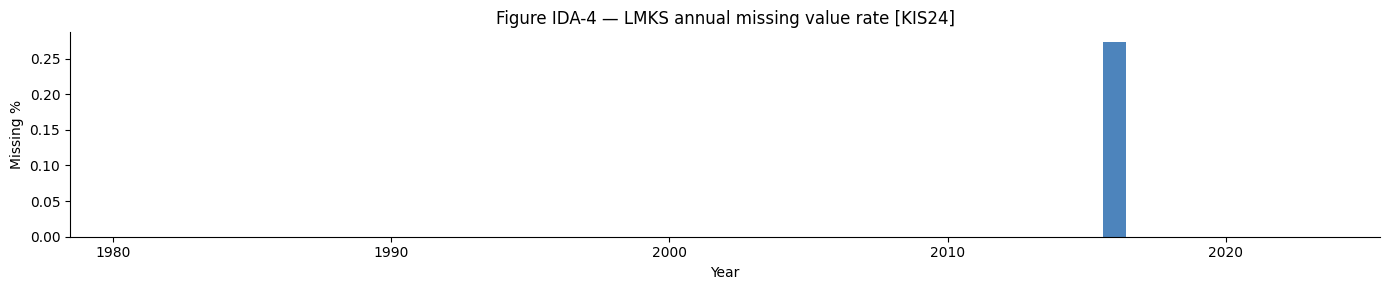

In [28]:
df_lmks['datetime'] = pd.to_datetime(df_lmks['datetime'])
df_lmks['YEAR'] = df_lmks['datetime'].dt.year

annual_lmks = df_lmks.groupby('YEAR')['lmks_nm_counts'].apply(
    lambda x: x.isnull().mean() * 100
)

fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(annual_lmks.index, annual_lmks, color='#2166ac', alpha=0.8, width=0.8)
ax.set_ylabel('Missing %')
ax.set_xlabel('Year')
ax.set_title('Figure IDA-4 — LMKS annual missing value rate [KIS24]')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('images/fig_ida4_lmks_missing.png', dpi=150, bbox_inches='tight')
plt.show()


**Observations — Figure IDA-4 — LMKS:**

The LMKS neutron count rate is almost entirely complete across the full 1981–2023 record. A single year (~2016) shows a missing rate of ~0.27% — corresponding to the 24 NaN values identified earlier. All other years have 0% missing. This confirms that the LMKS dataset `[KIS24]` is exceptionally clean and requires minimal treatment.